# Chapter 1: The coin

Companion notebook to `chapter.log`. Each loop below mirrors a section of the chapter narrative. Cells here use `expkit` to recreate the figures and numbers without reading from the saved data files. For the canonical reproducible artifacts, see `generate.py` and the `data/` folder.

Both lenses (frequentist + Bayesian via PyMC) appear in every loop.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from expkit.sim.coin import bernoulli_sequence, running_fraction
from expkit.inference.binomial import binom_test_exact, wilson_ci
from expkit.inference.bayes import (
    coin_posterior_conjugate,
    coin_posterior,
    posterior_summary,
)
from expkit.plot.style import apply_style, PALETTE
from expkit.plot.diagnostic import (
    plot_running_fraction,
    plot_running_fraction_with_band,
    plot_posterior_sequence,
)

apply_style()

## Loop A: a tiny coin experiment

Three tosses. Then seven more. We watch what each lens says at each step.

In [2]:
first_three = bernoulli_sequence(3, p=0.5, seed=4)
next_seven = bernoulli_sequence(7, p=0.5, seed=2)
ten = np.concatenate([first_three, next_seven])
print('first three :', first_three.tolist(), '  sum =', int(first_three.sum()))
print('next seven  :', next_seven.tolist(), '  sum =', int(next_seven.sum()))
print('combined ten:', ten.tolist(), '  sum =', int(ten.sum()))

first three : [1, 1, 1]   sum = 3
next seven  : [0, 0, 1, 0, 1, 1, 0]   sum = 3
combined ten: [1, 1, 1, 0, 0, 1, 0, 1, 1, 0]   sum = 6


In [3]:
# Frequentist: probability of HHH if fair, and exact binomial p-value at 6/10
p_HHH = 0.5 ** 3
test10 = binom_test_exact(int(ten.sum()), 10, p_null=0.5)
print(f'P(HHH | fair) = {p_HHH}')
print(f'binom test 6/10: p-value = {test10.p_value:.4f}, point estimate = {test10.point_estimate:.2f}')

P(HHH | fair) = 0.125
binom test 6/10: p-value = 0.7539, point estimate = 0.60


In [4]:
# Bayesian: closed-form Beta posterior after 3 tosses and after 10 tosses
post3 = coin_posterior_conjugate(first_three)
post10 = coin_posterior_conjugate(ten)
print(f'after HHH:  Beta({post3.alpha:.0f}, {post3.beta:.0f})  '
      f'mean={post3.mean:.3f}  P(p>0.5)={post3.prob_greater_than(0.5):.3f}')
print(f'after 10 :  Beta({post10.alpha:.0f}, {post10.beta:.0f})  '
      f'mean={post10.mean:.3f}  P(p>0.5)={post10.prob_greater_than(0.5):.3f}')

after HHH:  Beta(4, 1)  mean=0.800  P(p>0.5)=0.938
after 10 :  Beta(7, 5)  mean=0.583  P(p>0.5)=0.726


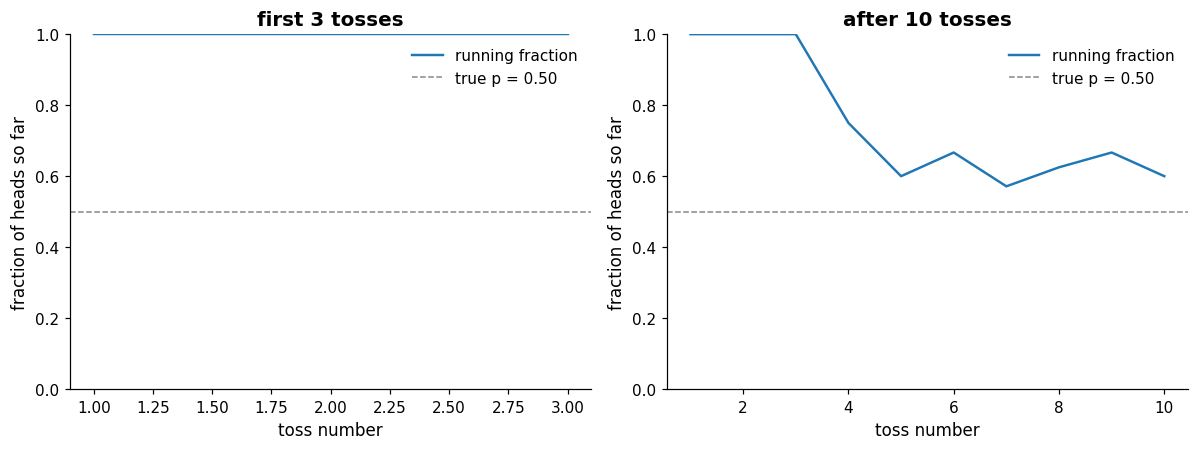

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
plot_running_fraction(first_three, ax=axes[0])
axes[0].set_title('first 3 tosses')
plot_running_fraction(ten, ax=axes[1])
axes[1].set_title('after 10 tosses')
fig.tight_layout()
plt.show()

## Loop B: 100 tosses, six seeds

Even a fair coin wobbles. We do not see exactly 0.5 in any single run.

In [6]:
seeds = [101, 102, 103, 104, 105, 106]
seqs = [bernoulli_sequence(100, 0.5, s) for s in seeds]
for s, seq in zip(seeds, seqs):
    print(f'seed {s}: {int(seq.sum())} heads in 100 tosses (fraction = {seq.mean():.2f})')

seed 101: 52 heads in 100 tosses (fraction = 0.52)
seed 102: 53 heads in 100 tosses (fraction = 0.53)
seed 103: 46 heads in 100 tosses (fraction = 0.46)
seed 104: 48 heads in 100 tosses (fraction = 0.48)
seed 105: 52 heads in 100 tosses (fraction = 0.52)
seed 106: 48 heads in 100 tosses (fraction = 0.48)


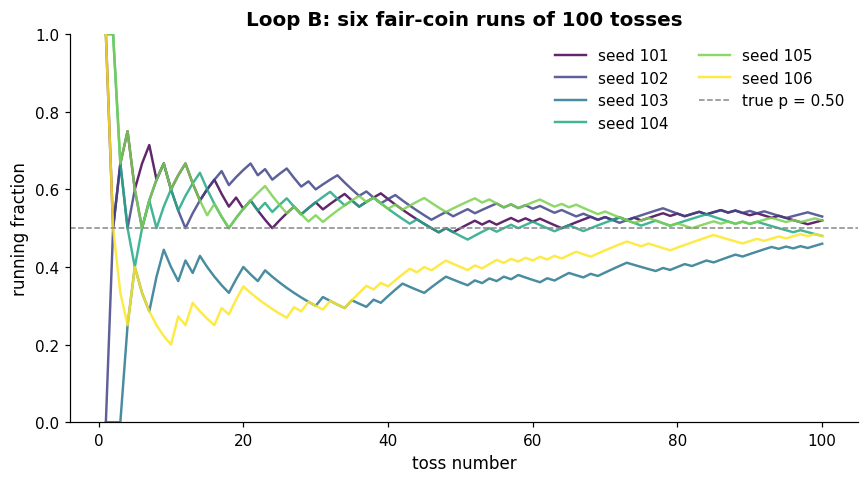

In [7]:
fig, ax = plt.subplots()
cmap = plt.get_cmap('viridis')
for i, seq in enumerate(seqs):
    ax.plot(np.arange(1, len(seq) + 1), running_fraction(seq),
            color=cmap(i / max(1, len(seqs) - 1)), alpha=0.85, label=f'seed {seeds[i]}')
ax.axhline(0.5, color=PALETTE['muted'], linestyle='--', linewidth=1, label='true p = 0.50')
ax.set_xlabel('toss number')
ax.set_ylabel('running fraction')
ax.set_ylim(0.0, 1.0)
ax.set_title('Loop B: six fair-coin runs of 100 tosses')
ax.legend(ncols=2)
fig.tight_layout()
plt.show()

## Loop C: 10,000 tosses, with Wilson band and Bayesian posterior tightening

PyMC is the canonical Bayesian engine. We also confirm the closed-form Beta posterior agrees, since this is a Bernoulli with a Beta prior.

In [8]:
long_seq = bernoulli_sequence(10000, 0.5, seed=7)
for n in [10, 100, 1000, 10000]:
    pre = long_seq[:n]
    k = int(pre.sum())
    lo, hi = wilson_ci(k, n)
    pc = coin_posterior_conjugate(pre)
    cl, ch = pc.credible_interval()
    print(f'N={n:>5}  k={k:>5}  Wilson [{lo:.3f},{hi:.3f}]  '
          f'Bayes mean={pc.mean:.3f}  CI [{cl:.3f},{ch:.3f}]')

N=   10  k=    6  Wilson [0.313,0.832]  Bayes mean=0.583  CI [0.308,0.833]
N=  100  k=   50  Wilson [0.404,0.596]  Bayes mean=0.500  CI [0.404,0.596]
N= 1000  k=  498  Wilson [0.467,0.529]  Bayes mean=0.498  CI [0.467,0.529]
N=10000  k= 5017  Wilson [0.492,0.511]  Bayes mean=0.502  CI [0.492,0.511]


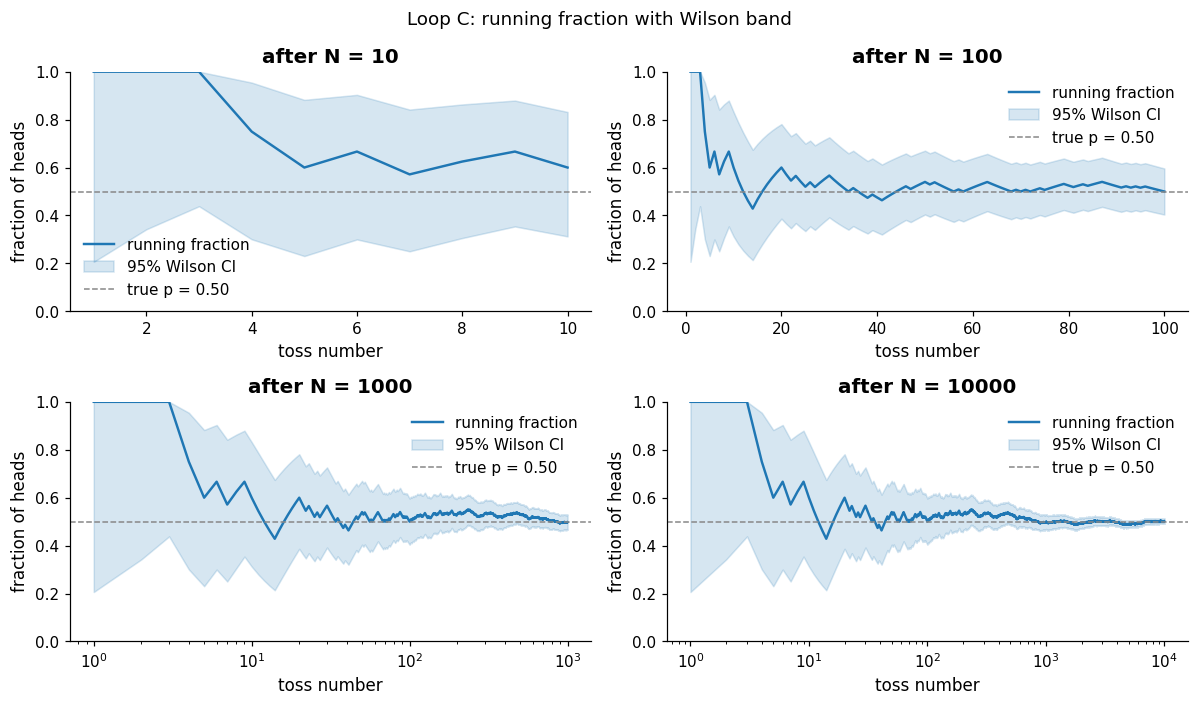

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
for ax, n in zip(axes.flat, [10, 100, 1000, 10000]):
    plot_running_fraction_with_band(long_seq[:n], ax=ax, alpha=0.05)
    ax.set_title(f'after N = {n}')
fig.suptitle('Loop C: running fraction with Wilson band')
fig.tight_layout()
plt.show()

In [10]:
# Bayesian posterior tightening using PyMC at four sample sizes.
# Kept small (1000 draws, 2 chains) so the cell runs in seconds on CPU.
snapshots = []
for n in [10, 100, 1000, 10000]:
    snapshots.append(coin_posterior(long_seq[:n], seed=999 + n, draws=1000, chains=2, tune=500, progressbar=False))
for n, idata in zip([10, 100, 1000, 10000], snapshots):
    s = posterior_summary(idata)
    print(f"N={n:>5}  posterior mean={s['mean']:.3f}  95% CI=[{s['ci_95_low']:.3f},{s['ci_95_high']:.3f}]  P(p>0.5)={s['prob_greater_half']:.3f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [p]


Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Multiprocess sampling (2 chains in 2 jobs)


NUTS: [p]


Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


N=   10  posterior mean=0.577  95% CI=[0.313,0.830]  P(p>0.5)=0.700
N=  100  posterior mean=0.497  95% CI=[0.396,0.591]  P(p>0.5)=0.492
N= 1000  posterior mean=0.498  95% CI=[0.469,0.529]  P(p>0.5)=0.458
N=10000  posterior mean=0.502  95% CI=[0.492,0.512]  P(p>0.5)=0.649


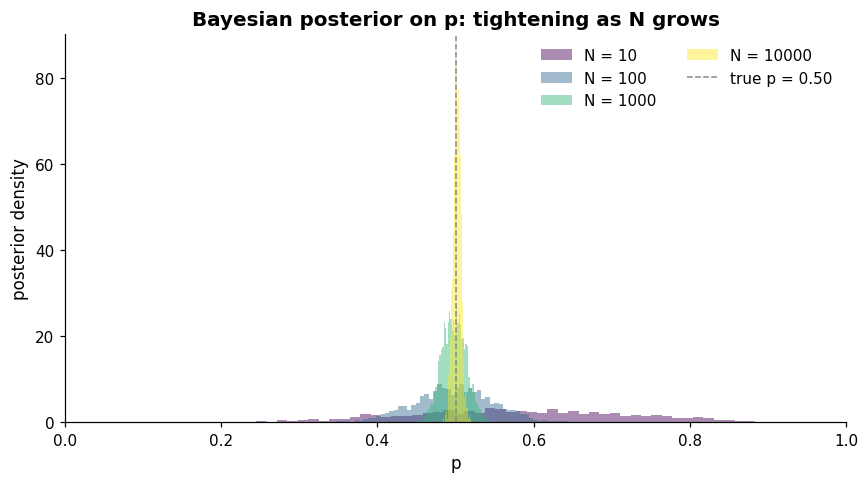

In [11]:
fig, ax = plt.subplots()
plot_posterior_sequence(snapshots, [10, 100, 1000, 10000], ax=ax, truth=0.5)
ax.set_title('Bayesian posterior on p: tightening as N grows')
fig.tight_layout()
plt.show()

## Loop D: fair vs slightly biased

p = 0.50 vs p = 0.55. At N = 10 they are indistinguishable. At N = 2000 they are obviously different.

In [12]:
fair = bernoulli_sequence(2000, p=0.50, seed=21)
biased = bernoulli_sequence(2000, p=0.55, seed=22)
print(f'fair coin   : {int(fair.sum())} heads in 2000 ({fair.mean():.3f})')
print(f'biased coin : {int(biased.sum())} heads in 2000 ({biased.mean():.3f})')

fair coin   : 1007 heads in 2000 (0.503)
biased coin : 1089 heads in 2000 (0.544)


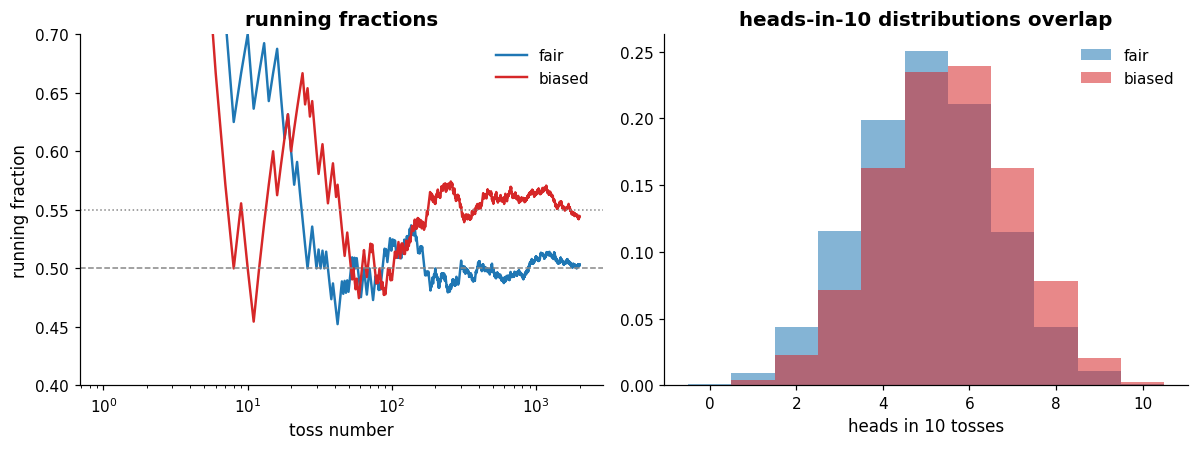

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(np.arange(1, len(fair) + 1), running_fraction(fair), color=PALETTE['frequentist'], label='fair')
axes[0].plot(np.arange(1, len(biased) + 1), running_fraction(biased), color=PALETTE['bayesian'], label='biased')
axes[0].axhline(0.5, color=PALETTE['muted'], linestyle='--', linewidth=1)
axes[0].axhline(0.55, color=PALETTE['muted'], linestyle=':', linewidth=1)
axes[0].set_xscale('log')
axes[0].set_ylim(0.4, 0.7)
axes[0].set_xlabel('toss number')
axes[0].set_ylabel('running fraction')
axes[0].set_title('running fractions')
axes[0].legend()
rng = np.random.default_rng(0)
fc = rng.binomial(10, 0.50, size=20000)
bc = rng.binomial(10, 0.55, size=20000)
bins = np.arange(-0.5, 11.5, 1.0)
axes[1].hist(fc, bins=bins, density=True, alpha=0.55, color=PALETTE['frequentist'], label='fair')
axes[1].hist(bc, bins=bins, density=True, alpha=0.55, color=PALETTE['bayesian'], label='biased')
axes[1].set_xlabel('heads in 10 tosses')
axes[1].set_title('heads-in-10 distributions overlap')
axes[1].legend()
fig.tight_layout()
plt.show()

## The big question

Both lenses agree on the easy cases (HHH alone is unconvincing; 5,000-ish heads in 10,000 tosses is convincingly fair). They differ on the harder middle cases. Chapter 2 makes those answers precise: null hypothesis, p-value, type I/II errors, posterior probability that p > 0.5, and Bayes factor.